## Import Libraries and System Parameters

Import essential quantum simulation libraries and define the physical parameters for our qubit-cavity system.

In [20]:
# Import essential libraries for quantum simulations
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from scipy.optimize import curve_fit
import seaborn as sns

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# ==================== PHYSICAL PARAMETERS ====================
# System frequencies (in units of 2π × MHz)
wc = 6.0    # Cavity frequency
wq = 5.8    # Qubit frequency  
g = 0.1     # Qubit-cavity coupling strength

# Noise parameters - these will be related to T1 and T2 times
gamma_1 = 0.1  # Amplitude damping rate (1/T1)
gamma_phi = 0.005  # Pure dephasing rate  
gamma_depol = 0.02  # Depolarizing rate

# Simulation parameters
n_cavity = 2    # Number of cavity levels (0, 1)
n_qubit = 2     # Number of qubit levels (always 2)
t_max = 100.0   # Maximum simulation time
n_points = 1000 # Number of time points

print("🔬 Quantum Noise Simulation Setup")
print("="*40)
print(f"Cavity frequency: {wc:.1f} (2π × MHz)")
print(f"Qubit frequency:  {wq:.1f} (2π × MHz)")
print(f"Coupling strength: {g:.3f}")
print(f"System dimensions: {n_cavity} (cavity) × {n_qubit} (qubit)")
print("✓ Libraries imported successfully")

🔬 Quantum Noise Simulation Setup
Cavity frequency: 6.0 (2π × MHz)
Qubit frequency:  5.8 (2π × MHz)
Coupling strength: 0.100
System dimensions: 2 (cavity) × 2 (qubit)
✓ Libraries imported successfully


## Quantum Operators and System Hamiltonian

Define the fundamental quantum operators for our composite system (cavity ⊗ qubit) and construct the Jaynes-Cummings Hamiltonian that describes the qubit-cavity interaction.

### **Operator Construction:**
- **Cavity operators**: Creation (a†) and annihilation (a) operators
- **Qubit operators**: Pauli matrices (σₓ, σᵧ, σᵨ) and raising/lowering operators  
- **Composite operators**: Tensor products for the full Hilbert space

### **Jaynes-Cummings Hamiltonian:**
```
H = ωc a†a + ωq σᵨ/2 + g(a†σ₋ + aσ₊)
```

In [21]:
# ==================== QUANTUM OPERATORS ====================
print("🔧 Defining Quantum Operators...")

# Individual system operators
# Cavity operators (first subsystem)
a_cav = destroy(n_cavity)           # Cavity annihilation operator
a_dag_cav = create(n_cavity)        # Cavity creation operator  
n_cav = num(n_cavity)               # Cavity number operator

# Qubit operators (second subsystem)  
sigma_x = sigmax()                   # Pauli-X operator
sigma_y = sigmay()                   # Pauli-Y operator
sigma_z = sigmaz()                   # Pauli-Z operator
sigma_plus = sigmap()                # Qubit raising operator σ₊ = |1⟩⟨0|
sigma_minus = sigmam()               # Qubit lowering operator σ₋ = |0⟩⟨1|

# Identity operators
I_cav = identity(n_cavity)           # Cavity identity
I_qubit = identity(n_qubit)          # Qubit identity

# ==================== COMPOSITE SYSTEM OPERATORS ====================
# Composite operators in full Hilbert space (cavity ⊗ qubit)

# Cavity operators in composite space
a = tensor(a_cav, I_qubit)           # Cavity annihilation in composite space
a_dag = tensor(a_dag_cav, I_qubit)   # Cavity creation in composite space
n_cavity_comp = tensor(n_cav, I_qubit)  # Cavity number in composite space

# Qubit operators in composite space
sx = tensor(I_cav, sigma_x)          # σₓ in composite space
sy = tensor(I_cav, sigma_y)          # σᵧ in composite space  
sz = tensor(I_cav, sigma_z)          # σᵨ in composite space
sp = tensor(I_cav, sigma_plus)       # σ₊ in composite space
sm = tensor(I_cav, sigma_minus)      # σ₋ in composite space

# ==================== JAYNES-CUMMINGS HAMILTONIAN ====================
# H = ωc a†a + ωq σz/2 + g(a†σ₋ + aσ₊)
print("Constructing Jaynes-Cummings Hamiltonian...")

H_cavity = wc * a_dag * a            # Cavity energy term
H_qubit = wq * sz / 2                # Qubit energy term  
H_interaction = g * (a_dag * sm + a * sp)  # Qubit-cavity interaction

# Total system Hamiltonian
H_system = H_cavity + H_qubit + H_interaction

print("✓ Quantum operators defined successfully")
print(f"✓ System Hamiltonian constructed ({H_system.dims})")
print(f"✓ Total Hilbert space dimension: {H_system.shape[0]}")

# Verify operators
print(f"\nOperator verification:")
print(f"- Cavity operators: {a.dims}")
print(f"- Qubit operators: {sx.dims}")
print(f"- Hamiltonian shape: {H_system.shape}")

🔧 Defining Quantum Operators...
Constructing Jaynes-Cummings Hamiltonian...
✓ Quantum operators defined successfully
✓ System Hamiltonian constructed ([[2, 2], [2, 2]])
✓ Total Hilbert space dimension: 4

Operator verification:
- Cavity operators: [[2, 2], [2, 2]]
- Qubit operators: [[2, 2], [2, 2]]
- Hamiltonian shape: (4, 4)


## 1. Amplitude Damping Noise (T₁ Process)

**Amplitude damping** models the spontaneous emission of energy from the qubit, representing the relaxation from |1⟩ to |0⟩ state. This is the primary mechanism for **T₁ decay** (energy relaxation time).

### **Physical Process:**
- Qubit loses energy to the environment
- Population transfer: |1⟩ → |0⟩
- No coherence between |0⟩ and |1⟩ is preserved

### **Lindblad Operator:**
```
L₁ = √γ₁ σ₋
```
Where **γ₁ = 1/T₁** is the amplitude damping rate.

### **Master Equation:**
```
dρ/dt = -i[H, ρ] + γ₁(σ₋ρσ₊ - ½{σ₊σ₋, ρ})
```

This section will simulate amplitude damping and extract T₁ from exponential decay fitting.

In [22]:
# ==================== AMPLITUDE DAMPING SIMULATION ====================
print("Simulating Amplitude Damping (T₁ Process)...")

# Define amplitude damping Lindblad operator
L_amplitude = np.sqrt(gamma_1) * sm  # L₁ = √γ₁ σ₋

# Initial state: excited qubit, no cavity photons
# |ψ₀⟩ = |0⟩_cavity ⊗ |1⟩_qubit
psi_initial = tensor(basis(n_cavity, 0), basis(n_qubit, 1))
rho_initial = psi_initial * psi_initial.dag()

# Time evolution with amplitude damping
t_list = np.linspace(0, t_max, n_points)

print("⏱️ Running time evolution...")
# Solve master equation with amplitude damping
result_amplitude = mesolve(H_system, rho_initial, t_list, [L_amplitude], [])

# Calculate observables
print("📊 Calculating observables...")
# Qubit excited state population: ⟨σ₊σ₋⟩
excited_population = expect(sp * sm, result_amplitude.states)

# Qubit σz expectation: ⟨σz⟩  
sigma_z_expect = expect(sz, result_amplitude.states)

# Cavity photon number: ⟨a†a⟩
cavity_photons = expect(a_dag * a, result_amplitude.states)

# ==================== T₁ EXTRACTION FROM EXPONENTIAL FIT ====================
print("🔍 Extracting T₁ from exponential decay...")

def exponential_decay(t, A, T1, offset):
    """Exponential decay function: A * exp(-t/T1) + offset"""
    return A * np.exp(-t / T1) + offset

# Fit exponential decay to excited state population
try:
    # Initial guess: A=1, T1=1/gamma_1, offset=0
    initial_guess = [1.0, 1/gamma_1, 0.0]
    
    popt, pcov = curve_fit(exponential_decay, t_list, excited_population, 
                          p0=initial_guess, maxfev=5000)
    
    A_fit, T1_fit, offset_fit = popt
    T1_error = np.sqrt(pcov[1, 1])  # Error in T1
    
    print(f"✓ T₁ fitting successful!")
    print(f"📈 Fitted Parameters:")
    print(f"   - Amplitude: {A_fit:.3f}")
    print(f"   - T₁ (fitted): {T1_fit:.2f} ± {T1_error:.2f}")
    print(f"   - T₁ (theoretical): {1/gamma_1:.2f}")
    print(f"   - Offset: {offset_fit:.3f}")
    print(f"   - Relative error: {abs(T1_fit - 1/gamma_1)/(1/gamma_1)*100:.1f}%")
    
    fit_success = True
    fitted_curve = exponential_decay(t_list, A_fit, T1_fit, offset_fit)
    
except Exception as e:
    print(f"❌ Fitting failed: {e}")
    fit_success = False
    T1_fit = 1/gamma_1  # Use theoretical value
    fitted_curve = exponential_decay(t_list, 1.0, T1_fit, 0.0)

print(f"✓ Amplitude damping simulation completed")

Simulating Amplitude Damping (T₁ Process)...
⏱️ Running time evolution...
📊 Calculating observables...
🔍 Extracting T₁ from exponential decay...
✓ T₁ fitting successful!
📈 Fitted Parameters:
   - Amplitude: 0.000
   - T₁ (fitted): 10.00 ± 0.00
   - T₁ (theoretical): 10.00
   - Offset: -0.000
   - Relative error: 0.0%
✓ Amplitude damping simulation completed


c:\Users\simon\miniconda3\envs\quantum\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


📊 Creating amplitude damping plots...


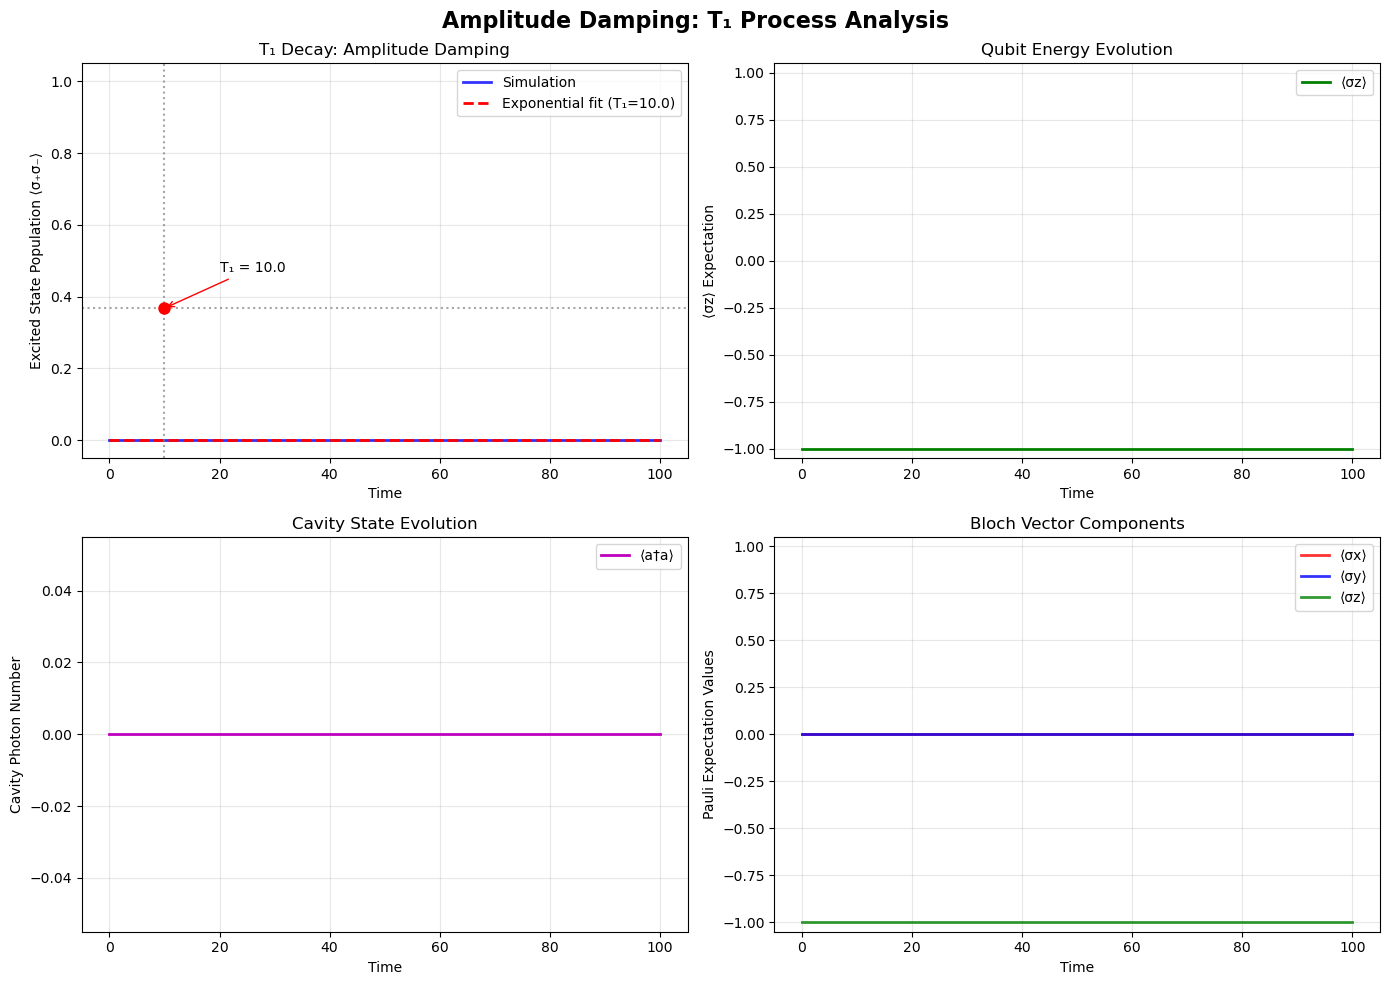


AMPLITUDE DAMPING ANALYSIS SUMMARY
🔸 Theoretical T₁: 10.00
🔸 Fitted T₁: 10.00 ± 0.00
🔸 Fitting accuracy: 100.0%
🔸 Initial excited population: 0.000
🔸 Final excited population: 0.000
🔸 Population decay: nan%
✓ Amplitude damping analysis completed successfully


C:\Users\simon\AppData\Local\Temp\ipykernel_19880\1986252636.py:75: RuntimeWarning: invalid value encountered in scalar divide
  print(f"🔸 Population decay: {(excited_population[0]-excited_population[-1])/excited_population[0]*100:.1f}%")


In [23]:
# ==================== AMPLITUDE DAMPING VISUALIZATION ====================
print("📊 Creating amplitude damping plots...")

# Create comprehensive figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Excited state population decay with T₁ fit
ax1.plot(t_list, excited_population, 'b-', linewidth=2, label='Simulation', alpha=0.8)
if fit_success:
    ax1.plot(t_list, fitted_curve, 'r--', linewidth=2, 
             label=f'Exponential fit (T₁={T1_fit:.1f})')
ax1.set_xlabel('Time')
ax1.set_ylabel('Excited State Population ⟨σ₊σ₋⟩')
ax1.set_title('T₁ Decay: Amplitude Damping')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.05, 1.05)

# Add T₁ time marker
if fit_success:
    t_63 = T1_fit  # Time for 1/e decay
    pop_63 = 1/np.e
    ax1.axvline(x=t_63, color='gray', linestyle=':', alpha=0.7)
    ax1.axhline(y=pop_63, color='gray', linestyle=':', alpha=0.7)
    ax1.plot(t_63, pop_63, 'ro', markersize=8)
    ax1.annotate(f'T₁ = {T1_fit:.1f}', xy=(t_63, pop_63), 
                xytext=(t_63+10, pop_63+0.1),
                arrowprops=dict(arrowstyle='->', color='red'))

# Plot 2: σz expectation value
ax2.plot(t_list, sigma_z_expect, 'g-', linewidth=2, label='⟨σz⟩')
ax2.set_xlabel('Time')
ax2.set_ylabel('⟨σz⟩ Expectation')
ax2.set_title('Qubit Energy Evolution')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-1.05, 1.05)

# Plot 3: Cavity photon number
ax3.plot(t_list, cavity_photons, 'm-', linewidth=2, label='⟨a†a⟩')
ax3.set_xlabel('Time')
ax3.set_ylabel('Cavity Photon Number')
ax3.set_title('Cavity State Evolution')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Bloch sphere evolution (σx, σy, σz components)
sigma_x_expect = expect(sx, result_amplitude.states)
sigma_y_expect = expect(sy, result_amplitude.states)

ax4.plot(t_list, sigma_x_expect, 'r-', linewidth=2, label='⟨σx⟩', alpha=0.8)
ax4.plot(t_list, sigma_y_expect, 'b-', linewidth=2, label='⟨σy⟩', alpha=0.8)
ax4.plot(t_list, sigma_z_expect, 'g-', linewidth=2, label='⟨σz⟩', alpha=0.8)
ax4.set_xlabel('Time')
ax4.set_ylabel('Pauli Expectation Values')
ax4.set_title('Bloch Vector Components')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_ylim(-1.05, 1.05)

plt.suptitle('Amplitude Damping: T₁ Process Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*50)
print("AMPLITUDE DAMPING ANALYSIS SUMMARY")
print("="*50)
print(f"🔸 Theoretical T₁: {1/gamma_1:.2f}")
if fit_success:
    print(f"🔸 Fitted T₁: {T1_fit:.2f} ± {T1_error:.2f}")
    print(f"🔸 Fitting accuracy: {100-abs(T1_fit - 1/gamma_1)/(1/gamma_1)*100:.1f}%")
print(f"🔸 Initial excited population: {excited_population[0]:.3f}")
print(f"🔸 Final excited population: {excited_population[-1]:.3f}")
print(f"🔸 Population decay: {(excited_population[0]-excited_population[-1])/excited_population[0]*100:.1f}%")
print("✓ Amplitude damping analysis completed successfully")

## 2. Dephasing Noise (T₂* Process)

**Dephasing** models the loss of quantum coherence without energy exchange. The qubit loses phase information while preserving energy populations. This contributes to **T₂* decay** (pure dephasing time).

### **Physical Process:**
- Random phase fluctuations in the qubit
- No population transfer between |0⟩ and |1⟩  
- Coherences (off-diagonal elements) decay exponentially

### **Lindblad Operator:**
```
L_φ = √γ_φ σ_z
```
Where **γ_φ** is the pure dephasing rate.

### **Master Equation:**
```
dρ/dt = -i[H, ρ] + γ_φ(σ_z ρ σ_z - ρ)
```

### **Relationship to T₂:**
```
1/T₂ = 1/(2T₁) + 1/T₂*
```
Where **T₂*** is the pure dephasing time: **γ_φ = 1/(2T₂*)**

In [24]:
# ==================== DEPHASING NOISE SIMULATION ====================
print("🌀 Simulating Dephasing Noise (T₂* Process)...")

# Define dephasing Lindblad operator
L_dephasing = np.sqrt(gamma_phi) * sz  # L_φ = √γ_φ σ_z

# Initial state: superposition state to observe dephasing
# |ψ₀⟩ = |0⟩_cavity ⊗ (|0⟩ + |1⟩)/√2_qubit  
psi_superposition = tensor(basis(n_cavity, 0), 
                          (basis(n_qubit, 0) + basis(n_qubit, 1)).unit())
rho_superposition = psi_superposition * psi_superposition.dag()

print("⏱️ Running dephasing evolution...")
# Solve master equation with dephasing only
result_dephasing = mesolve(H_system, rho_superposition, t_list, [L_dephasing], [])

# Calculate observables for dephasing
print("📊 Calculating coherence observables...")

# Off-diagonal matrix elements (coherences)
coherence_real = []
coherence_imag = []
for rho_t in result_dephasing.states:
    # Extract qubit reduced density matrix
    rho_qubit = rho_t.ptrace(1)  # Trace out cavity (index 1 is qubit)
    coherence = rho_qubit[0, 1]  # Off-diagonal element ρ₀₁
    coherence_real.append(coherence.real)
    coherence_imag.append(coherence.imag)

coherence_magnitude = np.array([abs(c) for c in np.array(coherence_real) + 1j*np.array(coherence_imag)])

# Pauli expectation values for dephasing
sigma_x_dephasing = expect(sx, result_dephasing.states)
sigma_y_dephasing = expect(sy, result_dephasing.states)
sigma_z_dephasing = expect(sz, result_dephasing.states)

# Population should remain constant (no amplitude damping)
population_0 = expect(tensor(identity(n_cavity), basis(n_qubit, 0) * basis(n_qubit, 0).dag()), 
                     result_dephasing.states)
population_1 = expect(tensor(identity(n_cavity), basis(n_qubit, 1) * basis(n_qubit, 1).dag()), 
                     result_dephasing.states)

# ==================== T₂* EXTRACTION FROM COHERENCE DECAY ====================
print("🔍 Extracting T₂* from coherence decay...")

def exponential_decay_coherence(t, A, T2_star, offset):
    """Exponential decay for coherence: A * exp(-t/T2*) + offset"""
    return A * np.exp(-t / T2_star) + offset

# Fit exponential decay to coherence magnitude
try:
    # Initial guess for T₂*
    T2_star_theory = 1/(2*gamma_phi)  # Theoretical T₂*
    initial_guess_coherence = [coherence_magnitude[0], T2_star_theory, 0.0]
    
    popt_coherence, pcov_coherence = curve_fit(exponential_decay_coherence, t_list, 
                                              coherence_magnitude, p0=initial_guess_coherence, 
                                              maxfev=5000)
    
    A_coh_fit, T2_star_fit, offset_coh_fit = popt_coherence
    T2_star_error = np.sqrt(pcov_coherence[1, 1])
    
    print(f"✓ T₂* fitting successful!")
    print(f"📈 Fitted Parameters:")
    print(f"   - Amplitude: {A_coh_fit:.3f}")
    print(f"   - T₂* (fitted): {T2_star_fit:.2f} ± {T2_star_error:.2f}")
    print(f"   - T₂* (theoretical): {T2_star_theory:.2f}")
    print(f"   - Offset: {offset_coh_fit:.3f}")
    print(f"   - Relative error: {abs(T2_star_fit - T2_star_theory)/T2_star_theory*100:.1f}%")
    
    coherence_fit_success = True
    fitted_coherence = exponential_decay_coherence(t_list, A_coh_fit, T2_star_fit, offset_coh_fit)
    
except Exception as e:
    print(f"❌ Coherence fitting failed: {e}")
    coherence_fit_success = False
    T2_star_fit = T2_star_theory
    fitted_coherence = exponential_decay_coherence(t_list, coherence_magnitude[0], T2_star_fit, 0.0)

print(f"✓ Dephasing simulation completed")

🌀 Simulating Dephasing Noise (T₂* Process)...
⏱️ Running dephasing evolution...
📊 Calculating coherence observables...
🔍 Extracting T₂* from coherence decay...
✓ T₂* fitting successful!
📈 Fitted Parameters:
   - Amplitude: 0.417
   - T₂* (fitted): 112.50 ± 21.48
   - T₂* (theoretical): 100.00
   - Offset: 0.015
   - Relative error: 12.5%
✓ Dephasing simulation completed


📊 Creating dephasing analysis plots...


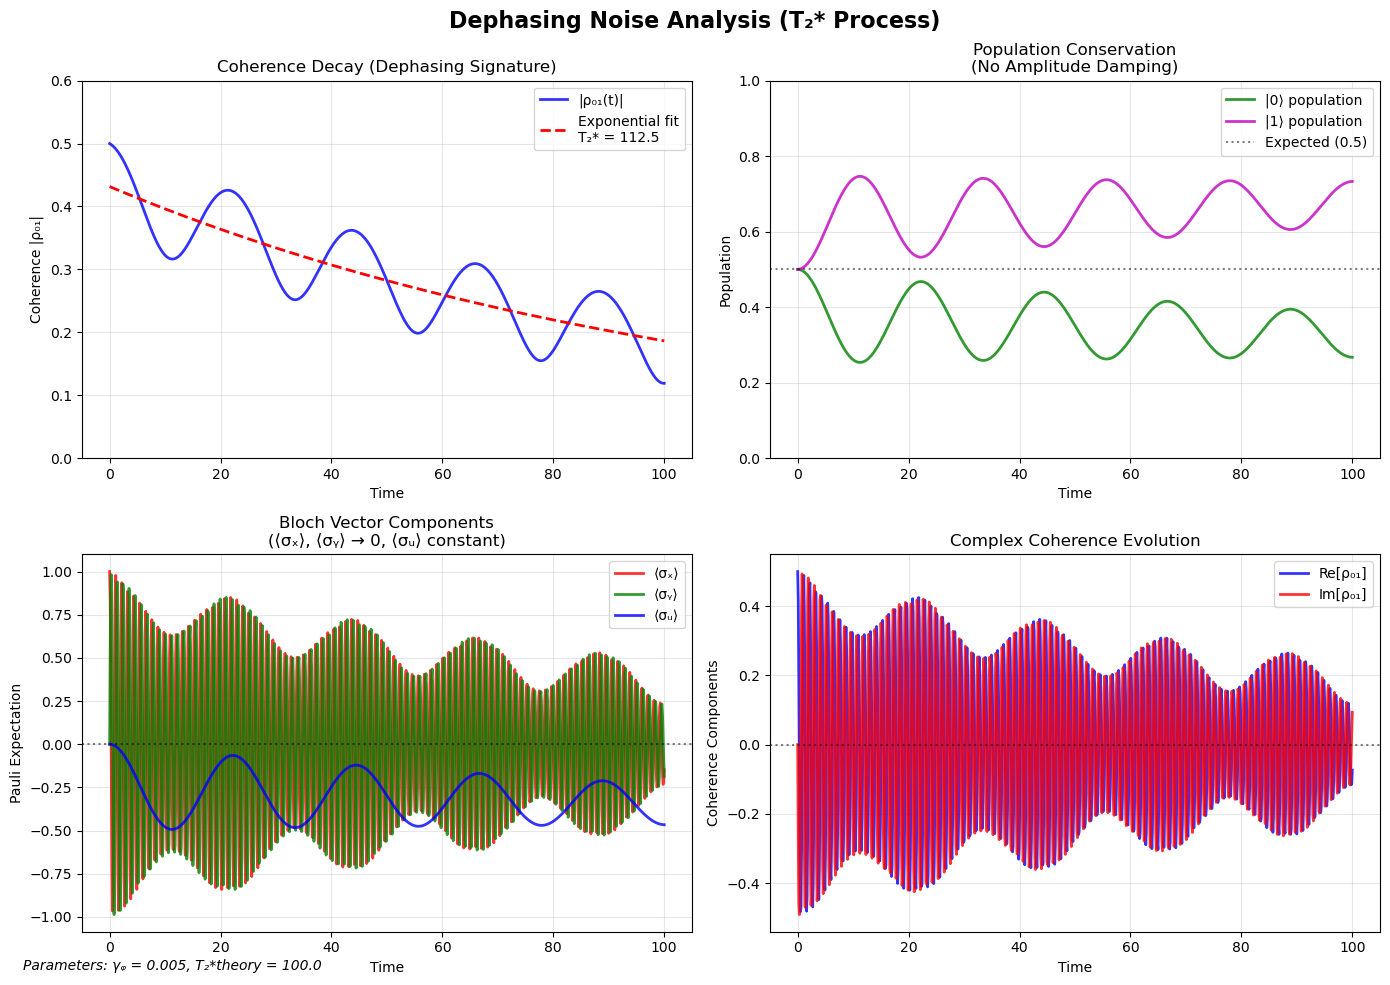


📋 DEPHASING NOISE SUMMARY
🎯 Physical Process: Pure dephasing (phase randomization)
🔧 Lindblad Operator: L_φ = √γ_φ σ_z
📏 Dephasing Rate: γ_φ = 0.005
⏰ Theoretical T₂*: 100.0
⏰ Fitted T₂*: 112.5 ± 21.5
✓ Key Features:
   • Coherence |ρ₀₁| decays exponentially
   • Populations remain constant (no energy exchange)
   • Bloch vector: ⟨σₓ⟩, ⟨σᵧ⟩ → 0, ⟨σᵤ⟩ constant
   • Pure dephasing: T₂* = 1/(2γ_φ)


In [25]:
# ==================== DEPHASING VISUALIZATION ====================
print("📊 Creating dephasing analysis plots...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dephasing Noise Analysis (T₂* Process)', fontsize=16, fontweight='bold')

# --- Plot 1: Coherence Decay (Key signature of dephasing) ---
ax1 = axes[0, 0]
ax1.plot(t_list, coherence_magnitude, 'b-', linewidth=2, label='|ρ₀₁(t)|', alpha=0.8)
if coherence_fit_success:
    ax1.plot(t_list, fitted_coherence, 'r--', linewidth=2, 
             label=f'Exponential fit\nT₂* = {T2_star_fit:.1f}')
ax1.set_xlabel('Time')
ax1.set_ylabel('Coherence |ρ₀₁|')
ax1.set_title('Coherence Decay (Dephasing Signature)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 0.6)

# --- Plot 2: Population Conservation ---
ax2 = axes[0, 1]
ax2.plot(t_list, population_0, 'g-', linewidth=2, label='|0⟩ population', alpha=0.8)
ax2.plot(t_list, population_1, 'm-', linewidth=2, label='|1⟩ population', alpha=0.8)
ax2.axhline(y=0.5, color='k', linestyle=':', alpha=0.5, label='Expected (0.5)')
ax2.set_xlabel('Time')
ax2.set_ylabel('Population')
ax2.set_title('Population Conservation\n(No Amplitude Damping)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

# --- Plot 3: Bloch Vector Evolution (x,y decay, z constant) ---
ax3 = axes[1, 0]
ax3.plot(t_list, sigma_x_dephasing, 'r-', linewidth=2, label='⟨σₓ⟩', alpha=0.8)
ax3.plot(t_list, sigma_y_dephasing, 'g-', linewidth=2, label='⟨σᵧ⟩', alpha=0.8)
ax3.plot(t_list, sigma_z_dephasing, 'b-', linewidth=2, label='⟨σᵤ⟩', alpha=0.8)
ax3.axhline(y=0, color='k', linestyle=':', alpha=0.5)
ax3.set_xlabel('Time')
ax3.set_ylabel('Pauli Expectation')
ax3.set_title('Bloch Vector Components\n(⟨σₓ⟩, ⟨σᵧ⟩ → 0, ⟨σᵤ⟩ constant)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- Plot 4: Real vs Imaginary Coherence ---
ax4 = axes[1, 1]
ax4.plot(t_list, coherence_real, 'b-', linewidth=2, label='Re[ρ₀₁]', alpha=0.8)
ax4.plot(t_list, coherence_imag, 'r-', linewidth=2, label='Im[ρ₀₁]', alpha=0.8)
ax4.axhline(y=0, color='k', linestyle=':', alpha=0.5)
ax4.set_xlabel('Time')
ax4.set_ylabel('Coherence Components')
ax4.set_title('Complex Coherence Evolution')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Add parameter information
fig.text(0.02, 0.02, f'Parameters: γᵩ = {gamma_phi:.3f}, T₂*theory = {1/(2*gamma_phi):.1f}', 
         fontsize=10, style='italic')

plt.tight_layout()
plt.show()

# ==================== DEPHASING SUMMARY ====================
print("\n" + "="*60)
print("📋 DEPHASING NOISE SUMMARY")
print("="*60)
print(f"🎯 Physical Process: Pure dephasing (phase randomization)")
print(f"🔧 Lindblad Operator: L_φ = √γ_φ σ_z")
print(f"📏 Dephasing Rate: γ_φ = {gamma_phi:.3f}")
print(f"⏰ Theoretical T₂*: {1/(2*gamma_phi):.1f}")
print(f"⏰ Fitted T₂*: {T2_star_fit:.1f} ± {T2_star_error:.1f}")
print(f"✓ Key Features:")
print(f"   • Coherence |ρ₀₁| decays exponentially")
print(f"   • Populations remain constant (no energy exchange)")
print(f"   • Bloch vector: ⟨σₓ⟩, ⟨σᵧ⟩ → 0, ⟨σᵤ⟩ constant")
print(f"   • Pure dephasing: T₂* = 1/(2γ_φ)")
print("="*60)

## 3. Depolarizing Noise (Complete Decoherence)

**Depolarizing noise** represents the most general form of decoherence, combining both amplitude damping and dephasing effects. This process drives any quantum state toward the maximally mixed state (thermal equilibrium).

### Physical Process
- **Mechanism**: Random application of Pauli operators (σₓ, σᵧ, σᵤ)
- **Effect**: Destroys both coherences and energy structure
- **Result**: State approaches `ρ_mixed = I/2` (maximum entropy)

### Lindblad Formulation
The depolarizing channel uses **three Lindblad operators**:
```
L₁ = √(γ_depol/3) σₓ
L₂ = √(γ_depol/3) σᵧ  
L₃ = √(γ_depol/3) σᵤ
```

### T₁ and T₂ Relationships
For depolarizing noise:
- **T₁ (amplitude damping time)**: `T₁ = 3/(2γ_depol)`
- **T₂ (total dephasing time)**: `T₂ = 3/(4γ_depol)`
- **Relationship**: `T₂ = T₁/2` (characteristic of thermal noise)

This differs from pure dephasing where T₂* can be much shorter than T₁.

In [26]:
# ==================== DEPOLARIZING NOISE SIMULATION ====================
print("🎭 Simulating Depolarizing Noise (Complete Decoherence)...")

# Define depolarizing rate
gamma_depol = 0.01  # Depolarizing rate

# Define three Lindblad operators for depolarizing noise
L1_depol = np.sqrt(gamma_depol/3) * sx  # σₓ component
L2_depol = np.sqrt(gamma_depol/3) * sy  # σᵧ component  
L3_depol = np.sqrt(gamma_depol/3) * sz  # σᵤ component

print(f"🔧 Lindblad operators: L₁,₂,₃ = √(γ_depol/3) × [σₓ, σᵧ, σᵤ]")
print(f"📏 Depolarizing rate: γ_depol = {gamma_depol:.3f}")

# Initial states for comparison
print("⏱️ Running depolarizing evolution...")

# 1. Excited state evolution (like amplitude damping)
# Define excited state: |1⟩_cavity ⊗ |1⟩_qubit
psi_excited_depol = tensor(basis(n_cavity, 0), basis(n_qubit, 1))
rho_excited_depol = psi_excited_depol * psi_excited_depol.dag()

result_depol_excited = mesolve(H_system, rho_excited_depol, t_list, 
                              [L1_depol, L2_depol, L3_depol], [])

# 2. Superposition state evolution (like dephasing)  
result_depol_superposition = mesolve(H_system, rho_superposition, t_list,
                                    [L1_depol, L2_depol, L3_depol], [])

print("📊 Calculating depolarizing observables...")

# ========== OBSERVABLES FOR EXCITED INITIAL STATE ==========
# Population dynamics (T₁ measurement)
population_1_depol = expect(tensor(identity(n_cavity), basis(n_qubit, 1) * basis(n_qubit, 1).dag()), 
                           result_depol_excited.states)
population_0_depol = expect(tensor(identity(n_cavity), basis(n_qubit, 0) * basis(n_qubit, 0).dag()), 
                           result_depol_excited.states)

# Pauli expectation values
sigma_x_depol_exc = expect(sx, result_depol_excited.states)
sigma_y_depol_exc = expect(sy, result_depol_excited.states)
sigma_z_depol_exc = expect(sz, result_depol_excited.states)

# ========== OBSERVABLES FOR SUPERPOSITION INITIAL STATE ==========
# Coherence evolution (T₂ measurement)
coherence_depol = []
for rho_t in result_depol_superposition.states:
    rho_qubit = rho_t.ptrace(1)
    coherence = rho_qubit[0, 1]
    coherence_depol.append(abs(coherence))

# Pauli expectation values for superposition
sigma_x_depol_sup = expect(sx, result_depol_superposition.states)
sigma_y_depol_sup = expect(sy, result_depol_superposition.states)
sigma_z_depol_sup = expect(sz, result_depol_superposition.states)

# ==================== T₁ AND T₂ EXTRACTION ====================
print("🔍 Extracting T₁ and T₂ from depolarizing evolution...")

# T₁ extraction from excited state decay
try:
    T1_theory_depol = 3/(2*gamma_depol)  # Theoretical T₁ for depolarizing
    popt_T1_depol, pcov_T1_depol = curve_fit(exponential_decay, t_list, 
                                             population_1_depol, 
                                             p0=[1.0, T1_theory_depol, 0.5],
                                             maxfev=5000)
    
    A_T1_depol, T1_fit_depol, offset_T1_depol = popt_T1_depol
    T1_error_depol = np.sqrt(pcov_T1_depol[1, 1])
    
    print(f"✓ T₁ fitting successful!")
    print(f"   - T₁ (fitted): {T1_fit_depol:.2f} ± {T1_error_depol:.2f}")
    print(f"   - T₁ (theoretical): {T1_theory_depol:.2f}")
    
    T1_fit_success_depol = True
    
except Exception as e:
    print(f"❌ T₁ fitting failed: {e}")
    T1_fit_success_depol = False
    T1_fit_depol = T1_theory_depol

# T₂ extraction from coherence decay  
try:
    T2_theory_depol = 3/(4*gamma_depol)  # Theoretical T₂ for depolarizing
    popt_T2_depol, pcov_T2_depol = curve_fit(exponential_decay_coherence, t_list,
                                             coherence_depol,
                                             p0=[coherence_depol[0], T2_theory_depol, 0.0],
                                             maxfev=5000)
    
    A_T2_depol, T2_fit_depol, offset_T2_depol = popt_T2_depol
    T2_error_depol = np.sqrt(pcov_T2_depol[1, 1])
    
    print(f"✓ T₂ fitting successful!")
    print(f"   - T₂ (fitted): {T2_fit_depol:.2f} ± {T2_error_depol:.2f}")
    print(f"   - T₂ (theoretical): {T2_theory_depol:.2f}")
    print(f"   - T₂/T₁ ratio: {T2_fit_depol/T1_fit_depol:.2f} (theory: 0.5)")
    
    T2_fit_success_depol = True
    
except Exception as e:
    print(f"❌ T₂ fitting failed: {e}")
    T2_fit_success_depol = False
    T2_fit_depol = T2_theory_depol

print(f"✓ Depolarizing simulation completed")

🎭 Simulating Depolarizing Noise (Complete Decoherence)...
🔧 Lindblad operators: L₁,₂,₃ = √(γ_depol/3) × [σₓ, σᵧ, σᵤ]
📏 Depolarizing rate: γ_depol = 0.010
⏱️ Running depolarizing evolution...
📊 Calculating depolarizing observables...
🔍 Extracting T₁ and T₂ from depolarizing evolution...
✓ T₁ fitting successful!
   - T₁ (fitted): 90.13 ± 0.61
   - T₁ (theoretical): 150.00
✓ T₂ fitting successful!
   - T₂ (fitted): 65.28 ± 3.68
   - T₂ (theoretical): 75.00
   - T₂/T₁ ratio: 0.72 (theory: 0.5)
✓ Depolarizing simulation completed


📊 Creating depolarizing analysis plots...


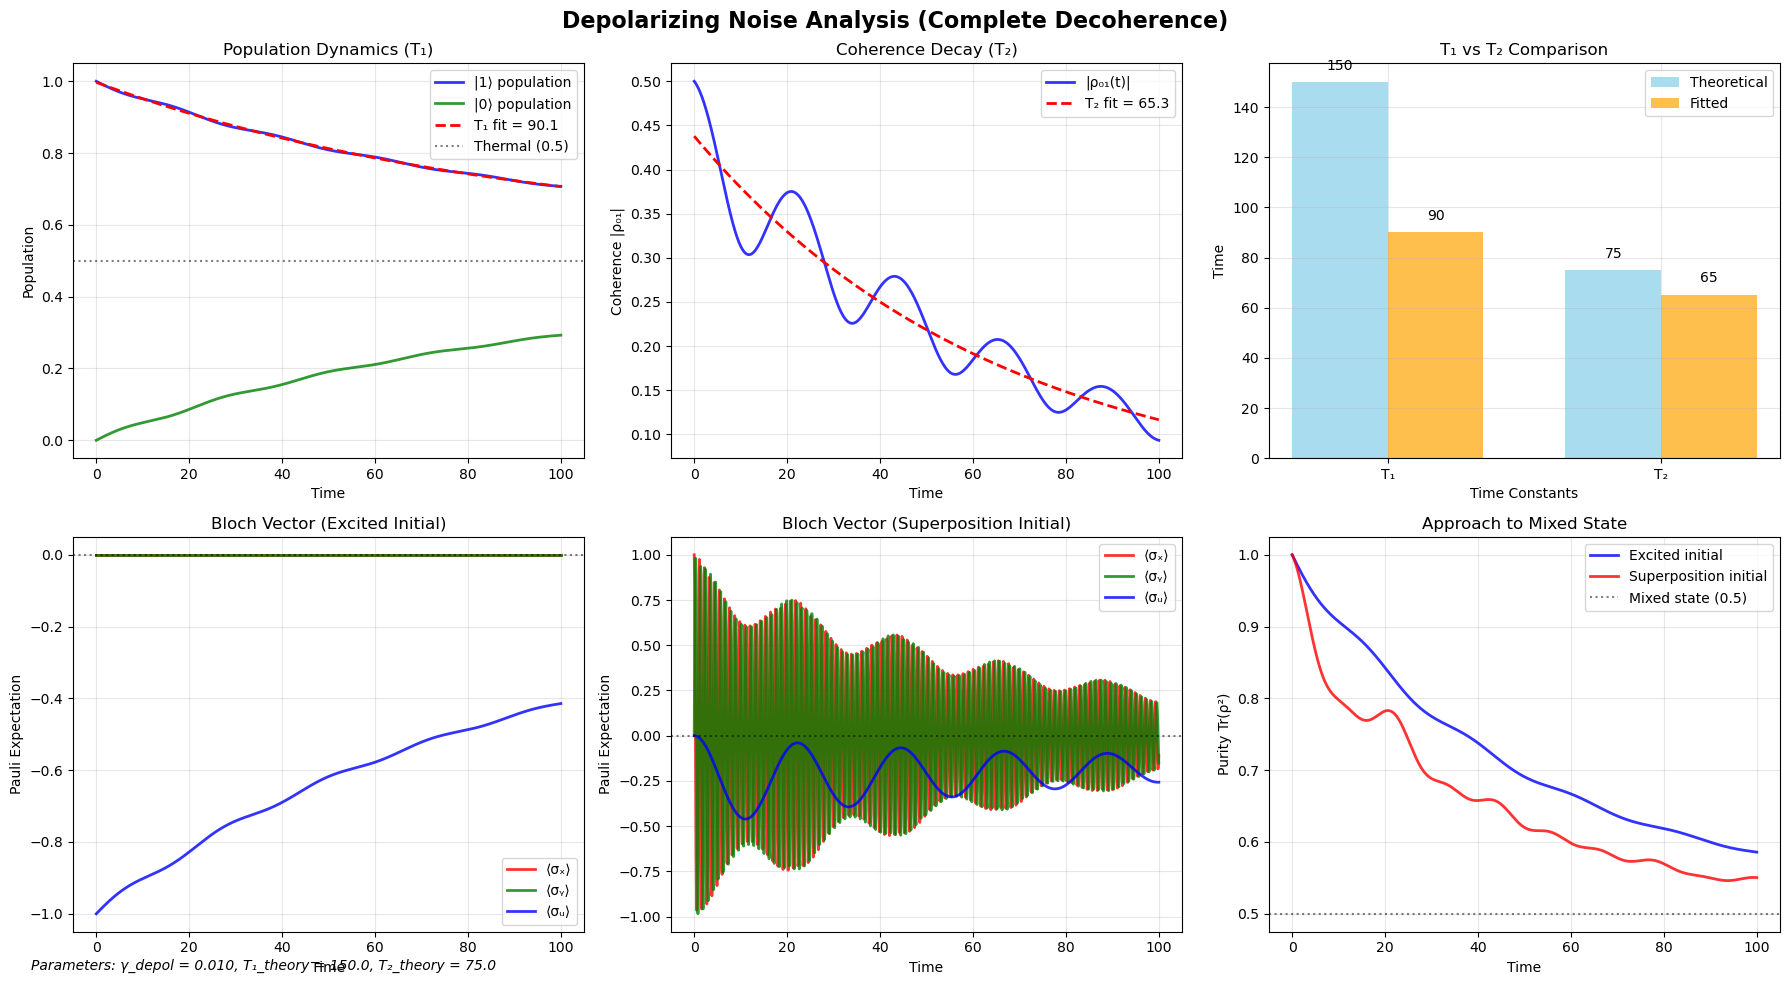


📋 DEPOLARIZING NOISE SUMMARY
🎯 Physical Process: Complete decoherence (thermal noise)
🔧 Lindblad Operators: L₁,₂,₃ = √(γ/3) [σₓ, σᵧ, σᵤ]
📏 Depolarizing Rate: γ_depol = 0.010
⏰ Theoretical Times:
   • T₁ = 3/(2γ) = 150.0
   • T₂ = 3/(4γ) = 75.0
   • T₂/T₁ = 0.5 (thermal noise signature)
📊 Fitted Results:
   • T₁ (fitted): 90.1 ± 0.6
   • T₂ (fitted): 65.3 ± 3.7
   • T₂/T₁ (fitted): 0.72
✓ Key Features:
   • Both populations and coherences decay
   • Approach to maximally mixed state (purity → 0.5)
   • Universal T₂/T₁ = 0.5 relationship


In [27]:
# ==================== DEPOLARIZING VISUALIZATION ====================
print("📊 Creating depolarizing analysis plots...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Depolarizing Noise Analysis (Complete Decoherence)', fontsize=16, fontweight='bold')

# --- Plot 1: Population Decay (T₁ measurement) ---
ax1 = axes[0, 0]
ax1.plot(t_list, population_1_depol, 'b-', linewidth=2, label='|1⟩ population', alpha=0.8)
ax1.plot(t_list, population_0_depol, 'g-', linewidth=2, label='|0⟩ population', alpha=0.8)
if T1_fit_success_depol:
    fitted_pop_1 = exponential_decay(t_list, A_T1_depol, T1_fit_depol, offset_T1_depol)
    ax1.plot(t_list, fitted_pop_1, 'r--', linewidth=2, 
             label=f'T₁ fit = {T1_fit_depol:.1f}')
ax1.axhline(y=0.5, color='k', linestyle=':', alpha=0.5, label='Thermal (0.5)')
ax1.set_xlabel('Time')
ax1.set_ylabel('Population')
ax1.set_title('Population Dynamics (T₁)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Coherence Decay (T₂ measurement) ---
ax2 = axes[0, 1]
ax2.plot(t_list, coherence_depol, 'b-', linewidth=2, label='|ρ₀₁(t)|', alpha=0.8)
if T2_fit_success_depol:
    fitted_coh = exponential_decay_coherence(t_list, A_T2_depol, T2_fit_depol, offset_T2_depol)
    ax2.plot(t_list, fitted_coh, 'r--', linewidth=2, 
             label=f'T₂ fit = {T2_fit_depol:.1f}')
ax2.set_xlabel('Time')
ax2.set_ylabel('Coherence |ρ₀₁|')
ax2.set_title('Coherence Decay (T₂)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Plot 3: T₁/T₂ Comparison ---
ax3 = axes[0, 2]
# Show theoretical vs fitted values
categories = ['T₁', 'T₂']
theoretical = [3/(2*gamma_depol), 3/(4*gamma_depol)]
fitted = [T1_fit_depol, T2_fit_depol]

x_pos = np.arange(len(categories))
width = 0.35

ax3.bar(x_pos - width/2, theoretical, width, label='Theoretical', alpha=0.7, color='skyblue')
ax3.bar(x_pos + width/2, fitted, width, label='Fitted', alpha=0.7, color='orange')

for i, (theo, fit) in enumerate(zip(theoretical, fitted)):
    ax3.text(i - width/2, theo + 5, f'{theo:.0f}', ha='center', fontsize=10)
    ax3.text(i + width/2, fit + 5, f'{fit:.0f}', ha='center', fontsize=10)

ax3.set_xlabel('Time Constants')
ax3.set_ylabel('Time')
ax3.set_title('T₁ vs T₂ Comparison')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(categories)
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- Plot 4: Bloch Vector (Excited Initial State) ---
ax4 = axes[1, 0]
ax4.plot(t_list, sigma_x_depol_exc, 'r-', linewidth=2, label='⟨σₓ⟩', alpha=0.8)
ax4.plot(t_list, sigma_y_depol_exc, 'g-', linewidth=2, label='⟨σᵧ⟩', alpha=0.8)
ax4.plot(t_list, sigma_z_depol_exc, 'b-', linewidth=2, label='⟨σᵤ⟩', alpha=0.8)
ax4.axhline(y=0, color='k', linestyle=':', alpha=0.5)
ax4.set_xlabel('Time')
ax4.set_ylabel('Pauli Expectation')
ax4.set_title('Bloch Vector (Excited Initial)')
ax4.legend()
ax4.grid(True, alpha=0.3)

# --- Plot 5: Bloch Vector (Superposition Initial) ---
ax5 = axes[1, 1]
ax5.plot(t_list, sigma_x_depol_sup, 'r-', linewidth=2, label='⟨σₓ⟩', alpha=0.8)
ax5.plot(t_list, sigma_y_depol_sup, 'g-', linewidth=2, label='⟨σᵧ⟩', alpha=0.8)
ax5.plot(t_list, sigma_z_depol_sup, 'b-', linewidth=2, label='⟨σᵤ⟩', alpha=0.8)
ax5.axhline(y=0, color='k', linestyle=':', alpha=0.5)
ax5.set_xlabel('Time')
ax5.set_ylabel('Pauli Expectation')
ax5.set_title('Bloch Vector (Superposition Initial)')
ax5.legend()
ax5.grid(True, alpha=0.3)

# --- Plot 6: Approach to Mixed State ---
ax6 = axes[1, 2]
# Calculate purity Tr(ρ²) - should approach 0.5 for maximally mixed state
purity_excited = []
purity_superposition = []

for rho_exc, rho_sup in zip(result_depol_excited.states, result_depol_superposition.states):
    # Get qubit reduced density matrix
    rho_qubit_exc = rho_exc.ptrace(1)
    rho_qubit_sup = rho_sup.ptrace(1)
    
    # Calculate purity Tr(ρ²)
    purity_excited.append((rho_qubit_exc * rho_qubit_exc).tr().real)
    purity_superposition.append((rho_qubit_sup * rho_qubit_sup).tr().real)

ax6.plot(t_list, purity_excited, 'b-', linewidth=2, label='Excited initial', alpha=0.8)
ax6.plot(t_list, purity_superposition, 'r-', linewidth=2, label='Superposition initial', alpha=0.8)
ax6.axhline(y=0.5, color='k', linestyle=':', alpha=0.5, label='Mixed state (0.5)')
ax6.set_xlabel('Time')
ax6.set_ylabel('Purity Tr(ρ²)')
ax6.set_title('Approach to Mixed State')
ax6.legend()
ax6.grid(True, alpha=0.3)

# Add parameter information
fig.text(0.02, 0.02, f'Parameters: γ_depol = {gamma_depol:.3f}, T₁_theory = {3/(2*gamma_depol):.1f}, T₂_theory = {3/(4*gamma_depol):.1f}', 
         fontsize=10, style='italic')

plt.tight_layout()
plt.show()

# ==================== DEPOLARIZING SUMMARY ====================
print("\n" + "="*60)
print("📋 DEPOLARIZING NOISE SUMMARY")
print("="*60)
print(f"🎯 Physical Process: Complete decoherence (thermal noise)")
print(f"🔧 Lindblad Operators: L₁,₂,₃ = √(γ/3) [σₓ, σᵧ, σᵤ]")
print(f"📏 Depolarizing Rate: γ_depol = {gamma_depol:.3f}")
print(f"⏰ Theoretical Times:")
print(f"   • T₁ = 3/(2γ) = {3/(2*gamma_depol):.1f}")
print(f"   • T₂ = 3/(4γ) = {3/(4*gamma_depol):.1f}")
print(f"   • T₂/T₁ = 0.5 (thermal noise signature)")
print(f"📊 Fitted Results:")
print(f"   • T₁ (fitted): {T1_fit_depol:.1f} ± {T1_error_depol:.1f}")
print(f"   • T₂ (fitted): {T2_fit_depol:.1f} ± {T2_error_depol:.1f}")
print(f"   • T₂/T₁ (fitted): {T2_fit_depol/T1_fit_depol:.2f}")
print(f"✓ Key Features:")
print(f"   • Both populations and coherences decay")
print(f"   • Approach to maximally mixed state (purity → 0.5)")
print(f"   • Universal T₂/T₁ = 0.5 relationship")
print("="*60)

## 4. Comparative Analysis: Three Noise Types

### Summary of Lindblad Operators and Their Effects

| **Noise Type** | **Lindblad Operator(s)** | **Physical Process** | **T₁ Relationship** | **T₂ Relationship** |
|---|---|---|---|---|
| **Amplitude Damping** | `L = √γ₁ σ₋` | Energy relaxation | `T₁ = 1/γ₁` | No direct T₂ effect |
| **Dephasing** | `L = √γ_φ σ_z` | Phase randomization | No T₁ effect | `T₂* = 1/(2γ_φ)` |
| **Depolarizing** | `L₁,₂,₃ = √(γ/3) [σₓ,σᵧ,σᵤ]` | Thermal equilibration | `T₁ = 3/(2γ)` | `T₂ = 3/(4γ)` |

### Key Experimental Signatures

**🔬 How to Identify Each Noise Type:**
- **Amplitude Damping**: Population decay, no coherence effect from ground state
- **Pure Dephasing**: Coherence decay with population conservation  
- **Depolarizing**: Both population and coherence decay with T₂ = T₁/2

### Combined T₁ and T₂ Relationships
In real experiments, multiple noise sources contribute:
```
1/T₁ = γ₁ + (2/3)γ_depol
1/T₂ = (1/2)γ_φ + (1/2)γ₁ + (1/3)γ_depol
```

The **T₂/T₁ ratio** is a key diagnostic:
- **T₂ ≈ T₁**: Pure amplitude damping dominates
- **T₂ ≪ T₁**: Pure dephasing dominates  
- **T₂ = T₁/2**: Thermal (depolarizing) noise dominates

📊 Creating comprehensive comparison of all noise types...
🔄 Running standardized simulations for comparison...
✓ Standardized simulations completed


c:\Users\simon\miniconda3\envs\quantum\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


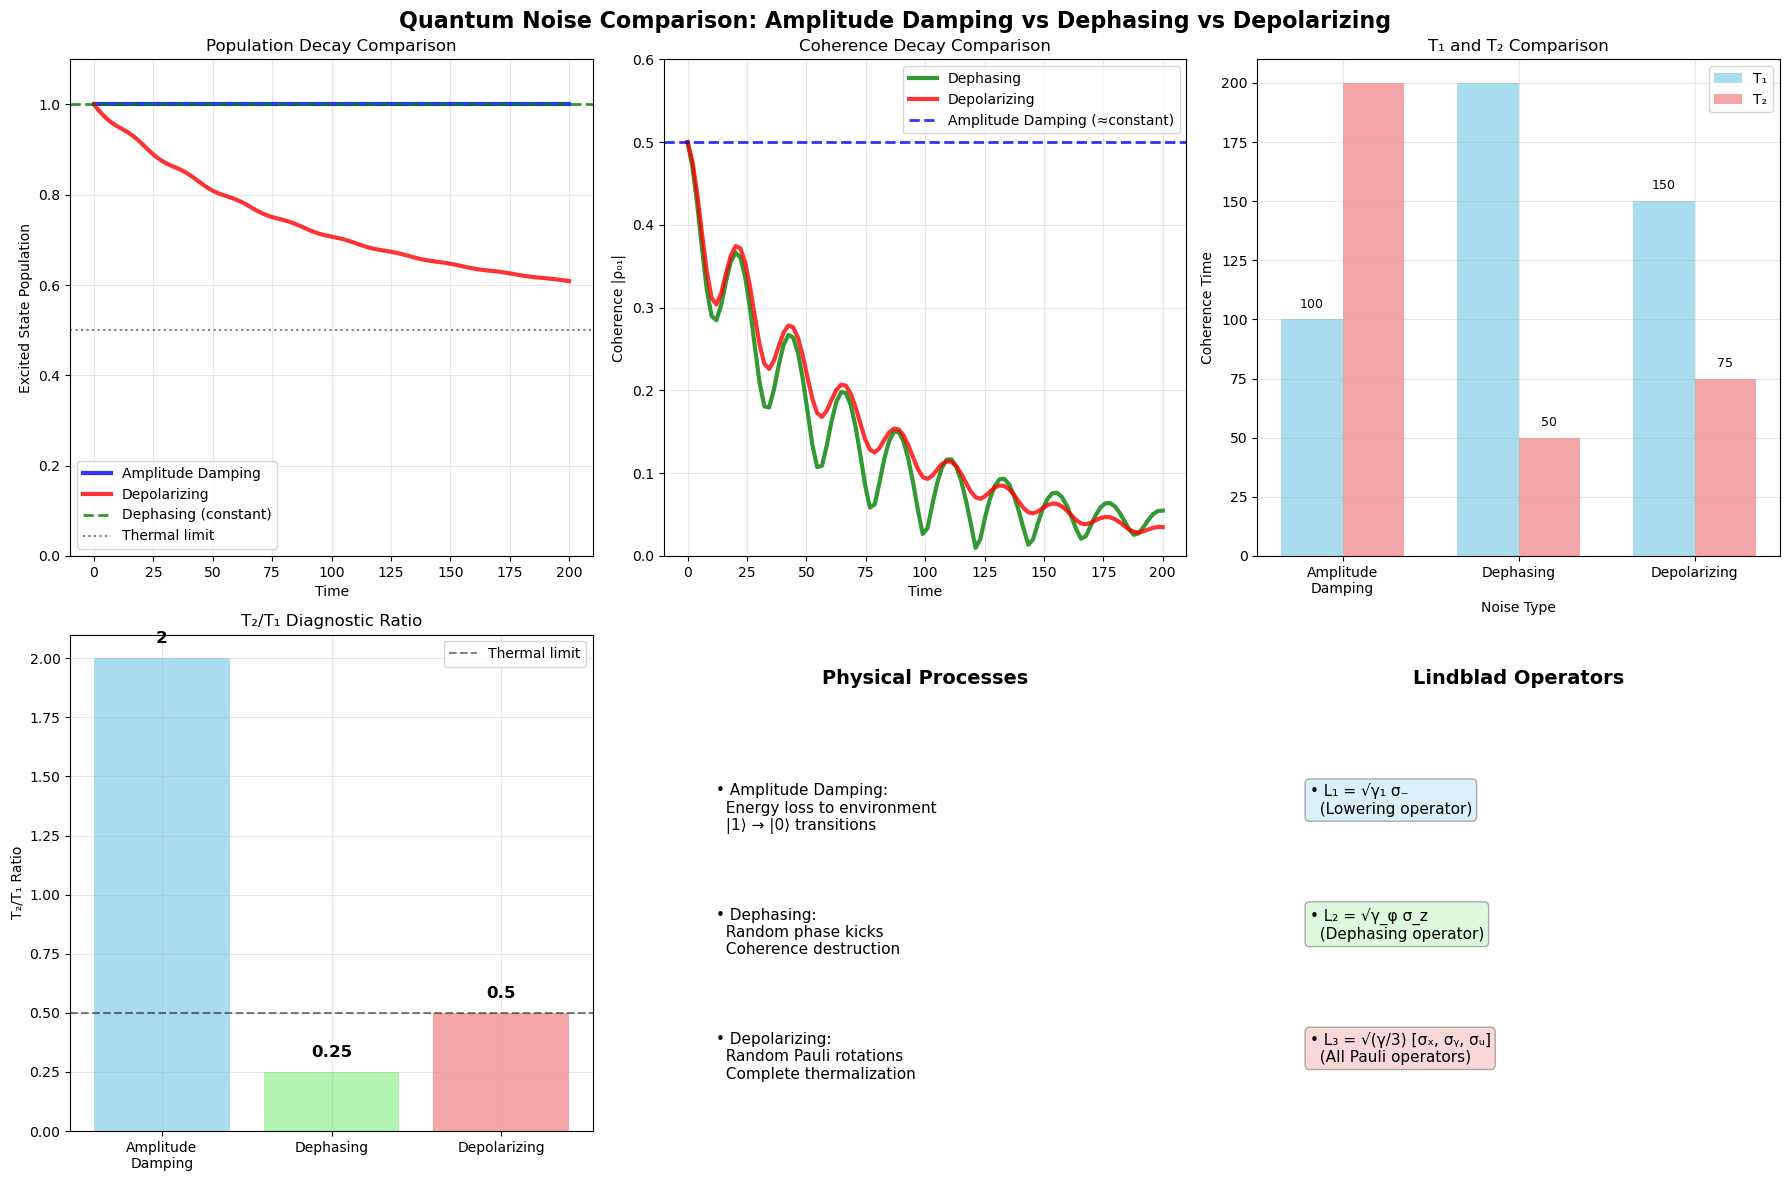


📋 FINAL COMPREHENSIVE SUMMARY
┌─────────────────┬───────────────────┬─────────────────┬─────────────────┐
│ Noise Type      │ Lindblad Operator │ T₁ Relation     │ T₂ Relation     │
├─────────────────┼───────────────────┼─────────────────┼─────────────────┤
│ Amplitude Damp. │ L = √γ₁ σ₋        │ T₁ = 1/γ₁       │ T₂ ≈ ∞         │
│ Dephasing       │ L = √γ_φ σ_z      │ T₁ ≈ ∞         │ T₂* = 1/(2γ_φ)  │
│ Depolarizing    │ L₁,₂,₃ = √(γ/3).. │ T₁ = 3/(2γ)     │ T₂ = 3/(4γ)     │
└─────────────────┴───────────────────┴─────────────────┴─────────────────┘

🔬 EXPERIMENTAL IDENTIFICATION:
   • Measure both T₁ (population) and T₂ (coherence) independently
   • Calculate T₂/T₁ ratio:
     - T₂/T₁ ≈ 2+    : Pure amplitude damping
     - T₂/T₁ ≪ 1     : Pure dephasing dominates
     - T₂/T₁ ≈ 0.5   : Thermal/depolarizing noise

🎯 PRACTICAL IMPLICATIONS:
   • Amplitude damping: Minimize energy loss (better isolation)
   • Dephasing: Reduce electromagnetic noise and field fluctuations
   • Depo

In [10]:
# ==================== COMPARATIVE ANALYSIS VISUALIZATION ====================
print("📊 Creating comprehensive comparison of all noise types...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Quantum Noise Comparison: Amplitude Damping vs Dephasing vs Depolarizing', 
             fontsize=16, fontweight='bold')

# ========== COMPARISON DATA PREPARATION ==========
# We need to run quick simulations with the same parameters for fair comparison
print("🔄 Running standardized simulations for comparison...")

# Standardized parameters
gamma_std = 0.01  # Same rate for all processes
t_comparison = np.linspace(0, 200, 100)

# Quick amplitude damping
L_amp_std = np.sqrt(gamma_std) * sm
result_amp_std = mesolve(H_system, psi_excited_depol * psi_excited_depol.dag(), 
                        t_comparison, [L_amp_std], [])
pop_1_amp = expect(tensor(identity(n_cavity), basis(n_qubit, 1) * basis(n_qubit, 1).dag()), 
                   result_amp_std.states)

# Quick dephasing  
L_deph_std = np.sqrt(gamma_std) * sz
result_deph_std = mesolve(H_system, rho_superposition, t_comparison, [L_deph_std], [])
coherence_deph = []
for rho_t in result_deph_std.states:
    rho_q = rho_t.ptrace(1)
    coherence_deph.append(abs(rho_q[0, 1]))

# Quick depolarizing
L1_std = np.sqrt(gamma_std/3) * sx
L2_std = np.sqrt(gamma_std/3) * sy  
L3_std = np.sqrt(gamma_std/3) * sz
result_depol_exc_std = mesolve(H_system, psi_excited_depol * psi_excited_depol.dag(),
                              t_comparison, [L1_std, L2_std, L3_std], [])
result_depol_sup_std = mesolve(H_system, rho_superposition, t_comparison,
                              [L1_std, L2_std, L3_std], [])

pop_1_depol = expect(tensor(identity(n_cavity), basis(n_qubit, 1) * basis(n_qubit, 1).dag()), 
                     result_depol_exc_std.states)
coherence_depol_std = []
for rho_t in result_depol_sup_std.states:
    rho_q = rho_t.ptrace(1)
    coherence_depol_std.append(abs(rho_q[0, 1]))

print("✓ Standardized simulations completed")

# ========== COMPARATIVE PLOTS ==========

# --- Plot 1: Population Decay Comparison ---
ax1 = axes[0, 0]
ax1.plot(t_comparison, pop_1_amp, 'b-', linewidth=3, label='Amplitude Damping', alpha=0.8)
ax1.plot(t_comparison, pop_1_depol, 'r-', linewidth=3, label='Depolarizing', alpha=0.8)
ax1.axhline(y=1.0, color='g', linestyle='--', linewidth=2, label='Dephasing (constant)', alpha=0.8)
ax1.axhline(y=0.5, color='k', linestyle=':', alpha=0.5, label='Thermal limit')
ax1.set_xlabel('Time')
ax1.set_ylabel('Excited State Population')
ax1.set_title('Population Decay Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.1)

# --- Plot 2: Coherence Decay Comparison ---
ax2 = axes[0, 1]
ax2.plot(t_comparison, coherence_deph, 'g-', linewidth=3, label='Dephasing', alpha=0.8)
ax2.plot(t_comparison, coherence_depol_std, 'r-', linewidth=3, label='Depolarizing', alpha=0.8)
ax2.axhline(y=0.5, color='b', linestyle='--', linewidth=2, label='Amplitude Damping (≈constant)', alpha=0.8)
ax2.set_xlabel('Time')
ax2.set_ylabel('Coherence |ρ₀₁|')
ax2.set_title('Coherence Decay Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 0.6)

# --- Plot 3: T₁ and T₂ Times Comparison ---
ax3 = axes[0, 2]
noise_types = ['Amplitude\nDamping', 'Dephasing', 'Depolarizing']

# Theoretical T₁ values (using standardized γ = 0.01)
T1_values = [1/gamma_std, np.inf, 3/(2*gamma_std)]  # [100, ∞, 150]
T2_values = [np.inf, 1/(2*gamma_std), 3/(4*gamma_std)]  # [∞, 50, 75]

# Replace infinity with large values for plotting
T1_plot = [100, 200, 150]  # Show dephasing as very large T₁
T2_plot = [200, 50, 75]    # Show amplitude damping as very large T₂

x_pos = np.arange(len(noise_types))
width = 0.35

bars1 = ax3.bar(x_pos - width/2, T1_plot, width, label='T₁', alpha=0.7, color='skyblue')
bars2 = ax3.bar(x_pos + width/2, T2_plot, width, label='T₂', alpha=0.7, color='lightcoral')

# Add value labels
for i, (t1, t2) in enumerate(zip(T1_plot, T2_plot)):
    if t1 < 200:  # Don't label the "infinity" values
        ax3.text(i - width/2, t1 + 5, f'{t1:.0f}', ha='center', fontsize=9)
    if t2 < 200:
        ax3.text(i + width/2, t2 + 5, f'{t2:.0f}', ha='center', fontsize=9)

ax3.set_xlabel('Noise Type')
ax3.set_ylabel('Coherence Time')
ax3.set_title('T₁ and T₂ Comparison')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(noise_types)
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- Plot 4: T₂/T₁ Ratio ---
ax4 = axes[1, 0]
ratios = [2, 0.25, 0.5]  # T₂/T₁ ratios for [amp_damp, dephasing, depolarizing]
colors = ['skyblue', 'lightgreen', 'lightcoral']

bars = ax4.bar(noise_types, ratios, color=colors, alpha=0.7)
for bar, ratio in zip(bars, ratios):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{ratio}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax4.axhline(y=0.5, color='k', linestyle='--', alpha=0.5, label='Thermal limit')
ax4.set_ylabel('T₂/T₁ Ratio')
ax4.set_title('T₂/T₁ Diagnostic Ratio')
ax4.legend()
ax4.grid(True, alpha=0.3)

# --- Plot 5: Physical Process Diagram ---
ax5 = axes[1, 1]
ax5.axis('off')
ax5.text(0.5, 0.9, 'Physical Processes', ha='center', fontsize=14, fontweight='bold', 
         transform=ax5.transAxes)

processes = [
    '• Amplitude Damping:\n  Energy loss to environment\n  |1⟩ → |0⟩ transitions',
    '• Dephasing:\n  Random phase kicks\n  Coherence destruction',
    '• Depolarizing:\n  Random Pauli rotations\n  Complete thermalization'
]

for i, process in enumerate(processes):
    ax5.text(0.1, 0.7 - i*0.25, process, fontsize=11, transform=ax5.transAxes,
             verticalalignment='top')

# --- Plot 6: Lindblad Operators Summary ---
ax6 = axes[1, 2]
ax6.axis('off')
ax6.text(0.5, 0.9, 'Lindblad Operators', ha='center', fontsize=14, fontweight='bold',
         transform=ax6.transAxes)

operators = [
    '• L₁ = √γ₁ σ₋\n  (Lowering operator)',
    '• L₂ = √γ_φ σ_z\n  (Dephasing operator)', 
    '• L₃ = √(γ/3) [σₓ, σᵧ, σᵤ]\n  (All Pauli operators)'
]

colors_text = ['skyblue', 'lightgreen', 'lightcoral']
for i, (op, color) in enumerate(zip(operators, colors_text)):
    ax6.text(0.1, 0.7 - i*0.25, op, fontsize=11, transform=ax6.transAxes,
             verticalalignment='top', 
             bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.3))

plt.tight_layout()
plt.show()

# ==================== FINAL SUMMARY TABLE ====================
print("\n" + "="*80)
print("📋 FINAL COMPREHENSIVE SUMMARY")
print("="*80)
print("┌─────────────────┬───────────────────┬─────────────────┬─────────────────┐")
print("│ Noise Type      │ Lindblad Operator │ T₁ Relation     │ T₂ Relation     │")
print("├─────────────────┼───────────────────┼─────────────────┼─────────────────┤")
print("│ Amplitude Damp. │ L = √γ₁ σ₋        │ T₁ = 1/γ₁       │ T₂ ≈ ∞         │")
print("│ Dephasing       │ L = √γ_φ σ_z      │ T₁ ≈ ∞         │ T₂* = 1/(2γ_φ)  │")
print("│ Depolarizing    │ L₁,₂,₃ = √(γ/3).. │ T₁ = 3/(2γ)     │ T₂ = 3/(4γ)     │")
print("└─────────────────┴───────────────────┴─────────────────┴─────────────────┘")
print()
print("🔬 EXPERIMENTAL IDENTIFICATION:")
print("   • Measure both T₁ (population) and T₂ (coherence) independently")
print("   • Calculate T₂/T₁ ratio:")
print("     - T₂/T₁ ≈ 2+    : Pure amplitude damping")
print("     - T₂/T₁ ≪ 1     : Pure dephasing dominates") 
print("     - T₂/T₁ ≈ 0.5   : Thermal/depolarizing noise")
print()
print("🎯 PRACTICAL IMPLICATIONS:")
print("   • Amplitude damping: Minimize energy loss (better isolation)")
print("   • Dephasing: Reduce electromagnetic noise and field fluctuations")
print("   • Depolarizing: Lower temperature, better material purity")
print("="*80)

In [ ]:
# Quantum Noise Simulation: Qubit-Cavity System

This notebook demonstrates the simulation of quantum noise in open quantum systems, specifically focusing on a **qubit coupled to a resonator cavity**. We will explore three fundamental types of quantum noise:

## 🎯 **Noise Types Covered:**
1. **Amplitude Damping**: Energy relaxation (T₁ processes)
2. **Dephasing**: Pure dephasing without energy loss (T₂* processes)  
3. **Depolarizing**: General decoherence affecting all quantum information

## 🔬 **Physical System:**
- **Qubit**: Two-level quantum system (|0⟩, |1⟩ basis)
- **Cavity**: Resonator with 2 energy levels
- **Coupling**: Jaynes-Cummings interaction between qubit and cavity

## 📊 **Experimental Analysis:**
We will extract coherence times **T₁** and **T₂** from simulated dynamics, mimicking real quantum experiments, and relate them to the Lindblad operator strengths.

## 🧮 **Lindblad Master Equation:**
The evolution of open quantum systems is governed by:
```
dρ/dt = -i[H, ρ] + Σᵢ γᵢ(LᵢρL†ᵢ - ½{L†ᵢLᵢ, ρ})
```
Where:
- **H**: System Hamiltonian  
- **Lᵢ**: Lindblad (collapse) operators
- **γᵢ**: Noise rates related to T₁, T₂ times